# Viscosity vs Temperature - Neo4j Query and Visualization

Query experiments containing:
- Water alone (only Water)
- Glycerol + Choline chloride (only these two)
- Water + Glycerol + Choline chloride (all three)

Filter for viscosity data and plot viscosity vs temperature grouped by mole fraction combinations.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from rich import print

In [2]:
# Neo4j connection parameters
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password"  # Update with your password

# Connect to Neo4j
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def test_connection():
    """Test the Neo4j connection"""
    with driver.session() as session:
        result = session.run("RETURN 1 as test")
        record = result.single()
        print(f"✅ Connected to Neo4j! Test result: {record['test']}")

test_connection()


✅ Connected to Neo4j! Test result: 1

In [3]:
# Debug: Check how many experiments exist in the database and how many match our criteria
debug_query = """
// Count total experiments
MATCH (e:Experiment)
WITH count(e) as total_experiments

// Count experiments with our target compounds
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT c.pubChemID) as compound_pids, total_experiments
WHERE ALL(pid IN compound_pids WHERE pid IN [962, 753, 6209])
  AND (
    (size(compound_pids) = 1 AND 962 IN compound_pids)
    OR
    (size(compound_pids) = 2 AND 753 IN compound_pids AND 6209 IN compound_pids AND NOT (962 IN compound_pids))
    OR
    (size(compound_pids) = 3 AND 753 IN compound_pids AND 962 IN compound_pids AND 6209 IN compound_pids)
  )
WITH count(DISTINCT e) as matching_experiments, total_experiments

// Count experiments with viscosity data
MATCH (e:Experiment)
WHERE e.prop_viscosity IS NOT NULL
   OR EXISTS {
     MATCH (e)-[:HAS_PROPERTY]->(p:Property)
     WHERE p.propertyType = 'viscosity' OR toLower(p.propertyType) CONTAINS 'viscosity'
   }
WITH count(DISTINCT e) as experiments_with_viscosity, matching_experiments, total_experiments

// Count matching experiments with viscosity
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT c.pubChemID) as compound_pids, experiments_with_viscosity, matching_experiments, total_experiments
WHERE ALL(pid IN compound_pids WHERE pid IN [962, 753, 6209])
  AND (
    (size(compound_pids) = 1 AND 962 IN compound_pids)
    OR
    (size(compound_pids) = 2 AND 753 IN compound_pids AND 6209 IN compound_pids AND NOT (962 IN compound_pids))
    OR
    (size(compound_pids) = 3 AND 753 IN compound_pids AND 962 IN compound_pids AND 6209 IN compound_pids)
  )
  AND (e.prop_viscosity IS NOT NULL OR EXISTS {
    MATCH (e)-[:HAS_PROPERTY]->(p:Property)
    WHERE p.propertyType = 'viscosity' OR toLower(p.propertyType) CONTAINS 'viscosity'
  })
WITH count(DISTINCT e) as matching_with_viscosity, experiments_with_viscosity, matching_experiments, total_experiments

RETURN total_experiments,
       matching_experiments,
       experiments_with_viscosity,
       matching_with_viscosity,
       round(100.0 * matching_experiments / total_experiments, 2) as pct_matching,
       round(100.0 * matching_with_viscosity / matching_experiments, 2) as pct_matching_with_viscosity
"""

with driver.session() as session:
    result = session.run(debug_query)
    record = result.single()
    if record:
        print("📊 Database Statistics:")
        print(f"   Total experiments in database: {record['total_experiments']}")
        print(f"   Experiments matching our criteria: {record['matching_experiments']} ({record['pct_matching']}%)")
        print(f"   Total experiments with viscosity: {record['experiments_with_viscosity']}")
        print(f"   Matching experiments with viscosity: {record['matching_with_viscosity']} ({record['pct_matching_with_viscosity']}%)")
    else:
        print("No data found")


📊 Database Statistics:

Total experiments in database: 663

Experiments matching our criteria: 647 (97.59%)

Total experiments with viscosity: 307

Matching experiments with viscosity: 307 (47.45%)

In [4]:
# Fix compound names: replace "(Oh)" with "(OH)"
df_ethylene_glycol_props['compounds'] = df_ethylene_glycol_props['compounds'].apply(
    lambda x: [comp.replace('(Oh)', '(OH)') for comp in x] if isinstance(x, list) else x
)


NameError: name 'df_ethylene_glycol_props' is not defined

## Query Experiments

Query experiments containing:
- Water alone (only Water, pubChemID=962)
- Glycerol + Choline chloride (only these two, pubChemID=753, 6209)
- Water + Glycerol + Choline chloride (all three, pubChemID=962, 753, 6209)

Including properties and parameters.


In [ ]:
# Define the Cypher query
# Find experiments containing:
# - Water alone (only Water, pubChemID=962)
# - Glycerol + Choline chloride (only these two, pubChemID=753, 6209)
# - Water + Glycerol + Choline chloride (all three, pubChemID=962, 753, 6209)
# Using PubChem IDs: Water=962, Glycerol=753, Choline chloride=6209
# Based on Neo4j structure: Experiments connect to Compounds via HAS_COMPOUND (with mole_fraction on edge),
# to Properties via HAS_PROPERTY (with value/uncertainty on edge), and to Parameters via HAS_PARAMETER
query = """
// Step 1: Find experiments that contain ONLY the allowed compounds
// Allowed: Water (962), Glycerol (753), Choline chloride (6209)
// Cases: Water alone, Glycerol+Choline chloride, or all three
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT {
    pubChemID: c.pubChemID,
    compoundID: c.compoundID, 
    commonName: c.commonName,
    mole_fraction: rcomp.mole_fraction
}) as compounds
WHERE ALL(c IN compounds WHERE c.pubChemID IN [962, 753, 6209])
  AND (
    // Case 1: Water alone (exactly 1 compound, must be Water)
    (size(compounds) = 1 AND ANY(c IN compounds WHERE c.pubChemID = 962))
    OR
    // Case 2: Glycerol + Choline chloride (exactly 2 compounds, must be these two)
    (size(compounds) = 2 
     AND ANY(c IN compounds WHERE c.pubChemID = 753)
     AND ANY(c IN compounds WHERE c.pubChemID = 6209)
     AND NOT ANY(c IN compounds WHERE c.pubChemID = 962))
    OR
    // Case 3: All three compounds (exactly 3 compounds, all must be present)
    (size(compounds) = 3
     AND ANY(c IN compounds WHERE c.pubChemID = 753)
     AND ANY(c IN compounds WHERE c.pubChemID = 962)
     AND ANY(c IN compounds WHERE c.pubChemID = 6209))
  )

// Step 2: Extract mole fractions for each compound by PubChem ID (use NULL if not present)
WITH e, compounds,
     [c IN compounds WHERE c.pubChemID = 753 | c.mole_fraction][0] as mole_fraction_1,  // Glycerol
     [c IN compounds WHERE c.pubChemID = 962 | c.mole_fraction][0] as mole_fraction_2,  // Water
     [c IN compounds WHERE c.pubChemID = 6209 | c.mole_fraction][0] as mole_fraction_3 // Choline chloride

// Step 3: Get temperature from HAS_PARAMETER relationship or from Experiment properties
OPTIONAL MATCH (e)-[rparam:HAS_PARAMETER]->(param:Parameter)
WHERE toLower(param.parameter) CONTAINS 'temperature' 
   OR toLower(param.parameterID) CONTAINS 'temperature'
WITH e, compounds, mole_fraction_1, mole_fraction_2, mole_fraction_3,
     COALESCE(
       [r IN collect(DISTINCT rparam.value) WHERE r IS NOT NULL][0],
       e.param_temperature
     ) as temperature

// Step 4: Match properties (especially viscosity) via HAS_PROPERTY relationship
OPTIONAL MATCH (e)-[rprop:HAS_PROPERTY]->(p:Property)
WHERE p.propertyType = 'viscosity' OR toLower(p.propertyType) CONTAINS 'viscosity'

// Step 5: Also get viscosity from Experiment properties as fallback
WITH e, compounds, mole_fraction_1, mole_fraction_2, mole_fraction_3, temperature,
     COALESCE(rprop.value, e.prop_viscosity) as property_value,
     rprop.uncertainty as property_uncertainty,
     COALESCE(p.propertyType, 'viscosity') as property_type
WHERE property_value IS NOT NULL AND temperature IS NOT NULL

// Step 6: Get compound information for display (match by PubChem ID)
MATCH (e)-[rcomp2:HAS_COMPOUND]->(c:Compound)
WHERE c.pubChemID IN [753, 962, 6209]  // Glycerol, Water, Choline chloride

RETURN DISTINCT
       e.experiment_id as experiment_id,
       c.compoundID as compound,
       c.commonName as compound_name,
       c.pubChemID as pubChemID,
       property_type,
       property_value,
       property_uncertainty,
       rcomp2.mole_fraction as mole_fraction,
       mole_fraction_1,
       mole_fraction_2,
       mole_fraction_3,
       temperature,
       e.method as method,
       e.source_file as source_file,
       e.source_doi as source_doi
ORDER BY e.experiment_id, c.pubChemID, property_type
"""

# Execute query and convert to DataFrame
with driver.session() as session:
    result = session.run(query)
    records = [dict(record) for record in result]
    
df = pd.DataFrame(records)

print(f"Retrieved {len(df)} records")
print(f"\nFirst few rows:")
df.head()


Retrieved 103 records

First few rows:

,experiment_id,compound,compound_name,pubChemID,property_type,property_value,property_uncertainty,mole_fraction,mole_fraction_1,mole_fraction_2,mole_fraction_3,temperature,method,source_file,source_doi
0,meas_viscosity_0839a7ea-ab66-4cb3-80a0-208242c...,Glycerol,Glycerol,753,viscosity,0.026333,None,0.667,0.667,NaN,0.333,353.15,measured,CHOLINE_CHLORIDE_glycerol.json,10.1016/j.fluid.2014.01.028
1,meas_viscosity_0839a7ea-ab66-4cb3-80a0-208242c...,Choline Chloride,Choline Chloride,6209,viscosity,0.026333,None,0.333,0.667,NaN,0.333,353.15,measured,CHOLINE_CHLORIDE_glycerol.json,10.1016/j.fluid.2014.01.028
2,meas_viscosity_127630e8-a37b-4d08-80d7-935307d...,Glycerol,Glycerol,753,viscosity,0.177000,None,0.667,0.667,NaN,0.333,298.15,measured,CHOLINE_CHLORIDE_glycerol.json,10.1016/j.jpha.2021.03.002
3,meas_viscosity_127630e8-a37b-4d08-80d7-935307d...,Choline Chloride,Choline Chloride,6209,viscosity,0.177000,None,0.333,0.667,NaN,0.333,298.15,measured,CHOLINE_CHLORIDE_glycerol.json,10.1016/j.jpha.2021.03.002
4,meas_viscosity_142381b6-b7be-49a6-a4db-10c2816...,Glycerol,Glycerol,753,viscosity,0.133375,None,0.667,0.667,NaN,0.333,313.15,measured,CHOLINE_CHLORIDE_glycerol.json,10.1016/j.fluid.2014.01.028


In [ ]:
# Filter for viscosity data only
df_viscosity = df[df['property_type'] == 'viscosity'].copy()

# Remove rows with missing temperature or viscosity values (mole fractions can be NULL for some mixtures)
df_viscosity = df_viscosity.dropna(subset=['temperature', 'property_value'])

# Multiply viscosity by 1000
df_viscosity['viscosity_1000'] = df_viscosity['property_value'] * 1000

# Create a label for mole fraction combination
# Handle NULL values: Water alone, Glycerol+Choline chloride, or all three
def create_mole_fraction_label(row):
    """Create label based on which compounds are present"""
    gly = row['mole_fraction_1']
    water = row['mole_fraction_2']
    chcl = row['mole_fraction_3']
    
    # Water alone
    if pd.notna(water) and pd.isna(gly) and pd.isna(chcl):
        return f"H₂O={water:.2f}"
    # Glycerol + Choline chloride
    elif pd.notna(gly) and pd.isna(water) and pd.notna(chcl):
        return f"Gly={gly:.2f}, ChCl={chcl:.2f}"
    # All three
    elif pd.notna(gly) and pd.notna(water) and pd.notna(chcl):
        return f"Gly={gly:.2f}, H₂O={water:.2f}, ChCl={chcl:.2f}"
    # Fallback: show what's available
    else:
        parts = []
        if pd.notna(gly):
            parts.append(f"Gly={gly:.2f}")
        if pd.notna(water):
            parts.append(f"H₂O={water:.2f}")
        if pd.notna(chcl):
            parts.append(f"ChCl={chcl:.2f}")
        return ", ".join(parts) if parts else "Unknown"

df_viscosity['mole_fraction_combo'] = df_viscosity.apply(create_mole_fraction_label, axis=1)

# Also create a mixture type column for easier filtering
def get_mixture_type(row):
    """Classify the mixture type"""
    gly = row['mole_fraction_1']
    water = row['mole_fraction_2']
    chcl = row['mole_fraction_3']
    
    if pd.notna(water) and pd.isna(gly) and pd.isna(chcl):
        return "Water alone"
    elif pd.notna(gly) and pd.isna(water) and pd.notna(chcl):
        return "Glycerol + Choline chloride"
    elif pd.notna(gly) and pd.notna(water) and pd.notna(chcl):
        return "Water + Glycerol + Choline chloride"
    else:
        return "Other"

df_viscosity['mixture_type'] = df_viscosity.apply(get_mixture_type, axis=1)

print(f"Viscosity data: {len(df_viscosity)} records")
print(f"\nMixture types:")
print(df_viscosity['mixture_type'].value_counts())
print(f"\nUnique mole fraction combinations:")
print(df_viscosity['mole_fraction_combo'].value_counts())


Viscosity data: 103 records

Mixture types:

mixture_type
Glycerol + Choline chloride            82
Water + Glycerol + Choline chloride    21
Name: count, dtype: int64

Unique mole fraction combinations:

mole_fraction_combo
Gly=0.67, ChCl=0.33              66
Gly=0.15, H₂O=0.77, ChCl=0.08    21
Gly=0.75, ChCl=0.25              16
Name: count, dtype: int64

## Visualization: Viscosity vs Temperature

### Plot 1: All Data Grouped by Mole Fraction Combinations


In [ ]:
# Create interactive plot with plotly - Arrhenius plot (ln viscosity vs 1/RT)
import numpy as np

fig = go.Figure()

# Gas constant in J/(mol·K)
R = 8.314

# Get unique mole fraction combinations
unique_combos = sorted(df_viscosity['mole_fraction_combo'].unique())

# Create color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Add a trace for each mole fraction combination
for idx, combo in enumerate(unique_combos):
    combo_data = df_viscosity[df_viscosity['mole_fraction_combo'] == combo].copy()
    
    # Calculate ln(viscosity) and 1/RT
    combo_data['ln_viscosity'] = np.log(combo_data['viscosity_1000'])
    combo_data['inv_RT'] = 1 / (R * combo_data['temperature'])
    
    # Sort by 1/RT for better line plots
    combo_data = combo_data.sort_values('inv_RT')
    
    # Add trace with markers and lines
    fig.add_trace(go.Scatter(
        x=combo_data['inv_RT'],
        y=combo_data['ln_viscosity'],
        mode='lines+markers',
        name=combo,
        line=dict(color=colors[idx % len(colors)], width=2),
        marker=dict(size=6, color=colors[idx % len(colors)]),
        hovertemplate='<b>%{fullData.name}</b><br>' +
                      '1/RT: %{x:.6f} mol/J<br>' +
                      'ln(Viscosity): %{y:.3f}<br>' +
                      'Temperature: %{customdata:.2f} K<br>' +
                      'Viscosity: %{text:.2f} mPa·s<br>' +
                      '<extra></extra>',
        customdata=combo_data['temperature'],
        text=combo_data['viscosity_1000']
    ))

# Update layout
fig.update_layout(
    title='Arrhenius Plot: ln(Viscosity) vs 1/RT (Grouped by Mole Fraction Combinations)',
    xaxis_title='1/RT (mol/J)',
    yaxis_title='ln(Viscosity) [ln(mPa·s)]',
    hovermode='closest',
    template='plotly_white',
    width=1000,
    height=600,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01
    )
)

# Show the interactive plot
fig.show()


In [ ]:
import pandas as pd

viscosity_all_compounds_query = """
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
MATCH (e)-[r:HAS_PROPERTY]->(p:Property)
WHERE p.propertyType = 'viscosity'
OPTIONAL MATCH (p)-[:HAS_UNIT]->(u:Unit)
OPTIONAL MATCH (e)-[rparam:HAS_PARAMETER]->(param:Parameter)
WHERE toLower(param.parameter) CONTAINS 'temperature' 
   OR toLower(param.parameterID) CONTAINS 'temperature'
MATCH (e)-[rcomp2:HAS_COMPOUND]->(c2:Compound)
WITH e, r, p, rparam, collect(DISTINCT {name: c2.commonName, mole_fraction: rcomp2.mole_fraction}) AS compound_data
WITH e, r, p, rparam, compound_data,
     [comp IN compound_data | comp.name] AS compounds,
     compound_data AS compound_fractions
RETURN e.experiment_id                AS experiment_id,
       e.source_doi                   AS source_doi,
       p.propertyType                 AS property_type,
       r.value                        AS property_value,
       r.uncertainty                  AS property_uncertainty,
       rparam.value                   AS temperature,
       rparam.uncertainty             AS temperature_uncertainty,
       compounds,
       compound_fractions
ORDER BY experiment_id, property_type
"""

with driver.session() as session:
    df_viscosity_all = pd.DataFrame(session.run(viscosity_all_compounds_query).data())

# Convert compounds list to string for drop_duplicates to work properly
df_viscosity_all['compounds_str'] = df_viscosity_all['compounds'].astype(str)
df_viscosity_all['compound_fractions_str'] = df_viscosity_all['compound_fractions'].astype(str)
df_viscosity_all = df_viscosity_all.drop_duplicates(subset=['property_type', 'property_value', 'temperature'])
df_viscosity_all = df_viscosity_all.drop(columns=['compounds_str', 'compound_fractions_str'])
df_viscosity_all = df_viscosity_all.sort_values('source_doi')
df_viscosity_all

/tmp/ipykernel_11175/1168131298.py:28: DeprecationWarning:

Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.



,experiment_id,source_doi,property_type,property_value,property_uncertainty,temperature,temperature_uncertainty,compounds,compound_fractions
1401,meas_viscosity_a1a56c84-9c2b-4546-a383-b696eed...,10.1002/apj.1873,viscosity,0.0401,None,293.15,None,"[Phenol, Choline Chloride]","[{'name': 'Phenol', 'mole_fraction': 0.8}, {'n..."
1681,meas_viscosity_c0ff3678-0764-4c57-a00e-c657996...,10.1002/apj.1873,viscosity,0.0260,None,298.15,None,"[Ethylene Glycol, Choline Chloride]","[{'name': 'Ethylene Glycol', 'mole_fraction': ..."
80,meas_viscosity_08f70e33-10d0-4f67-b5e0-c97930d...,10.1002/apj.1873,viscosity,0.0903,None,333.15,None,"[Malonic Acid, Choline Chloride]","[{'name': 'Malonic Acid', 'mole_fraction': 0.6..."
1285,meas_viscosity_95717e4e-4b37-457b-a700-6dd2b21...,10.1002/apj.1873,viscosity,0.0252,None,303.15,None,"[Choline Chloride, Phenol]","[{'name': 'Choline Chloride', 'mole_fraction':..."
1140,meas_viscosity_84168116-459c-44c5-b6ba-8e0aeee...,10.1002/apj.1873,viscosity,0.2000,None,313.15,None,"[Choline Chloride, Malonic Acid]","[{'name': 'Choline Chloride', 'mole_fraction':..."
...,...,...,...,...,...,...,...,...,...
190,meas_viscosity_14b80b9f-7e6a-4db5-a296-a80aa1b...,Quirin,viscosity,0.0662,None,298.15,None,"[Ethylene Glycol, N1142(Oh)Cl]","[{'name': 'Ethylene Glycol', 'mole_fraction': ..."
754,meas_viscosity_58618291-42dc-42bf-9cbc-22acf1b...,Quirin,viscosity,0.0906,None,293.15,None,"[Ethylene Glycol, N1152(Oh)Br]","[{'name': 'Ethylene Glycol', 'mole_fraction': ..."
443,meas_viscosity_33896789-23c4-4e57-be28-99dc477...,Quirin,viscosity,0.0835,None,293.15,None,"[N1142(Oh)Cl, Ethylene Glycol]","[{'name': 'N1142(Oh)Cl', 'mole_fraction': 0.33..."
1664,meas_viscosity_bf3cba20-31ae-4f56-aa85-11239a5...,Quirin,viscosity,0.0529,None,293.15,None,"[N1122(Oh)Br, Ethylene Glycol]","[{'name': 'N1122(Oh)Br', 'mole_fraction': 0.33..."


/tmp/ipykernel_11175/2794931305.py:125: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



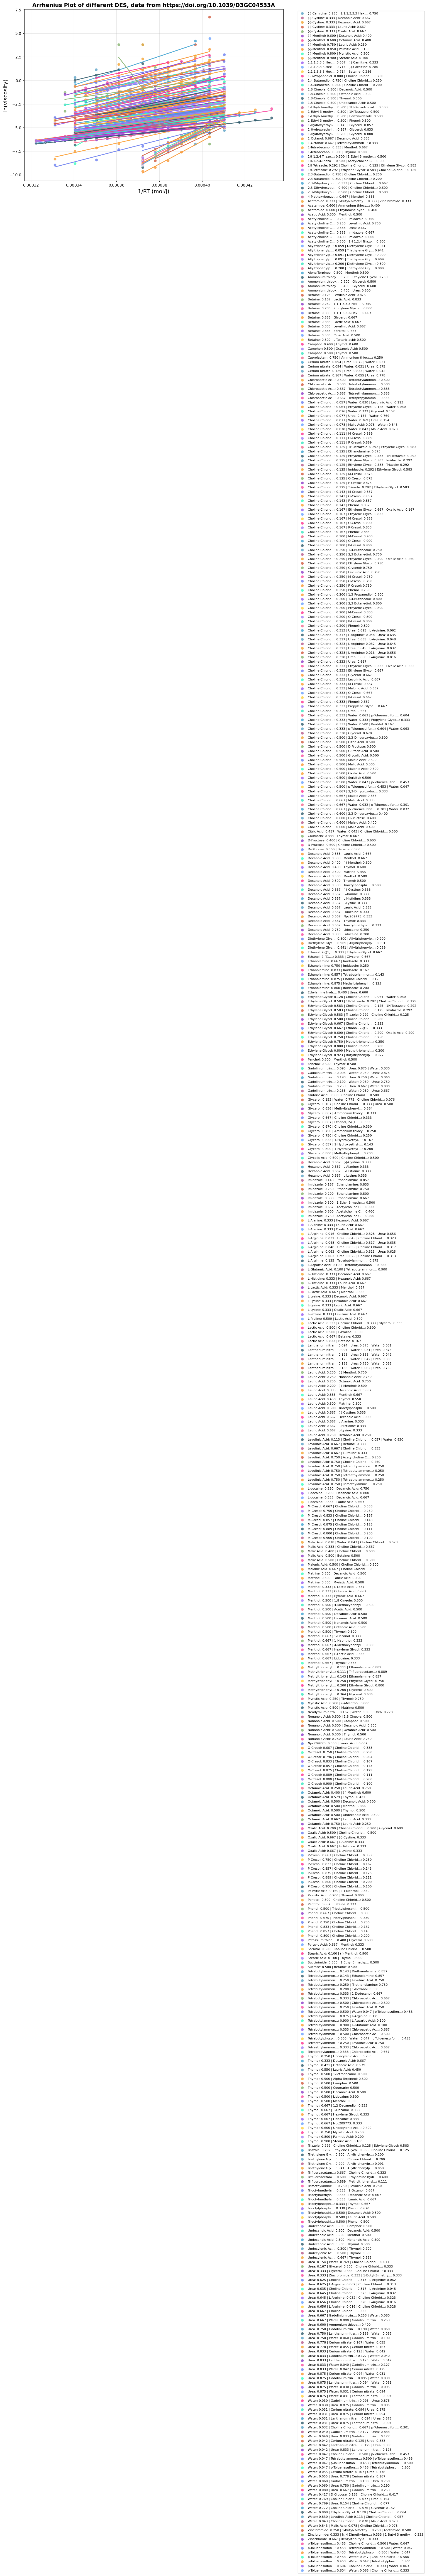

✅ Created Arrhenius plot with 1816 data points from 573 compound fraction combinations

📊 Temperature range: 278.1 - 373.1 K

📊 Viscosity range: 0.0001 - 834.1140 Pa·s

📁 Saved high resolution plot: arrhenius_plot_high_res.png (300 DPI)

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create Arrhenius plot from df_viscosity_all (excluding "Quirin" data)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Filter out "Quirin" data
df_viscosity_filtered = df_viscosity_all[~df_viscosity_all['source_doi'].str.contains('Quirin', na=False)].copy()

# Convert temperature and viscosity to numeric
df_viscosity_filtered['temperature'] = pd.to_numeric(df_viscosity_filtered['temperature'], errors='coerce')
df_viscosity_filtered['property_value'] = pd.to_numeric(df_viscosity_filtered['property_value'], errors='coerce')

# Remove rows with missing temperature or viscosity data
df_viscosity_filtered = df_viscosity_filtered.dropna(subset=['temperature', 'property_value'])

# Calculate Arrhenius plot variables
R = 8.314  # J/(mol·K)
df_viscosity_filtered['inv_RT'] = 1 / (R * df_viscosity_filtered['temperature'])
df_viscosity_filtered['ln_viscosity'] = np.log(df_viscosity_filtered['property_value'])

# Create the plot with white background
fig, ax1 = plt.subplots(figsize=(12, 8))
plt.style.use('default')  # Ensure white background

# Group by compound_fractions for different markers
df_viscosity_filtered['compound_fractions_str'] = df_viscosity_filtered['compound_fractions'].astype(str)
unique_compound_fractions = sorted(df_viscosity_filtered['compound_fractions_str'].dropna().unique())

# Use high-quality color palette with good contrast and visual appeal (lighter shades)
high_quality_colors = [
    '#5BA3C7',  # Lighter ocean blue
    '#B85A8A',  # Lighter deep magenta
    '#F4A533',  # Lighter vibrant orange
    '#D15A3F',  # Lighter rich red
    '#85B36E',  # Lighter forest green
    '#8E3BC7',  # Lighter royal purple
    '#F94FA3',  # Lighter hot pink
    '#6B7EF0',  # Lighter electric blue
    '#F99733',  # Lighter amber
    '#3AFFC0',  # Lighter mint green
    '#FCA033',  # Lighter burnt orange
    '#9B5EF0',  # Lighter violet
    '#6BA3FF',  # Lighter bright blue
    '#FFD03D',  # Lighter golden yellow
    '#FF3390',  # Lighter fuchsia
    '#A47EF8',  # Lighter light purple
    '#38E6C0',  # Lighter teal
    '#F2698F',  # Lighter coral
    '#3FA3D2',  # Lighter steel blue
    '#2F5B6C'   # Lighter dark teal
]

# Tile colors to ensure we have enough for all compound fractions
colors = np.array(high_quality_colors * (len(unique_compound_fractions) // len(high_quality_colors) + 1))[:len(unique_compound_fractions)]

# Add scatter points and fit lines for each compound fraction combination
for frac_idx, compound_frac in enumerate(unique_compound_fractions):
    frac_data = df_viscosity_filtered[df_viscosity_filtered['compound_fractions_str'] == compound_frac]
    
    if len(frac_data) > 0:
        # Create a readable label from compound fractions
        try:
            # Parse the compound fractions to create a readable label
            fractions = eval(compound_frac)  # Convert string back to list
            if isinstance(fractions, list) and len(fractions) > 0:
                label_parts = []
                for comp in fractions:
                    if isinstance(comp, dict) and 'name' in comp and 'mole_fraction' in comp:
                        name = comp['name'][:15] + "..." if len(comp['name']) > 15 else comp['name']
                        label_parts.append(f"{name}: {comp['mole_fraction']:.3f}")
                label = " | ".join(label_parts)
            else:
                label = f"Fraction {frac_idx + 1}"
        except:
            label = f"Fraction {frac_idx + 1}"
        
        # Plot scatter points using circles only
        ax1.scatter(
            frac_data['inv_RT'],
            frac_data['ln_viscosity'],
            marker='o',
            s=60,
            color=colors[frac_idx],
            alpha=0.8,
            edgecolors='white',
            linewidth=1.0,
            label=label
        )
        
        # Fit and plot trend line only if we have 3 or more points
        if len(frac_data) >= 3:
            X = frac_data['inv_RT'].values.reshape(-1, 1)
            y = frac_data['ln_viscosity'].values
            
            # Fit linear regression
            reg = LinearRegression().fit(X, y)
            
            # Generate line points
            x_line = np.linspace(frac_data['inv_RT'].min(), frac_data['inv_RT'].max(), 100)
            y_line = reg.predict(x_line.reshape(-1, 1))
            
            # Plot trend line
            ax1.plot(
                x_line,
                y_line,
                color=colors[frac_idx],
                linestyle='-',
                alpha=0.9,
                linewidth=2.0
            )

# Customize the primary plot
ax1.set_xlabel('1/RT (mol/J)', fontsize=14)
ax1.set_ylabel('ln(viscosity)', fontsize=14)
ax1.set_title('Arrhenius Plot of different DES, data from https://doi.org/10.1039/D3GC04533A', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Show legend
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Set white background
ax1.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

print(f"✅ Created Arrhenius plot with {len(df_viscosity_filtered)} data points from {len(unique_compound_fractions)} compound fraction combinations")
print(f"📊 Temperature range: {df_viscosity_filtered['temperature'].min():.1f} - {df_viscosity_filtered['temperature'].max():.1f} K")
print(f"📊 Viscosity range: {df_viscosity_filtered['property_value'].min():.4f} - {df_viscosity_filtered['property_value'].max():.4f} Pa·s")
# Save high resolution plot as PNG
plt.savefig('/home/sga/Schreibtisch/arrhenius_plot_high_res.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("📁 Saved high resolution plot: arrhenius_plot_high_res.png (300 DPI)")




### Plot 2: Single Plot - Color by Mole Fraction, Shape by Source DOI


In [ ]:
# Create single plot: color by mole fraction, shape by source_doi
fig = go.Figure()

# Get unique mole fraction combinations and source DOIs
unique_combos = sorted(df_viscosity['mole_fraction_combo'].unique())
unique_dois = sorted(df_viscosity['source_doi'].dropna().unique())

# Color palette for mole fractions
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Marker shapes for different DOIs (circle, square, diamond, triangle, etc.)
marker_symbols = ['circle', 'square', 'diamond', 'triangle-up', 'triangle-down', 
                  'triangle-left', 'triangle-right', 'star', 'pentagon', 'hexagon',
                  'cross', 'x', 'diamond-wide', 'diamond-tall']

print(f"Found {len(unique_dois)} unique source DOIs")
print(f"Found {len(unique_combos)} unique mole fraction combinations")

# Create traces for each combination of (mole_fraction_combo, source_doi)
for combo_idx, combo in enumerate(unique_combos):
    combo_color = colors[combo_idx % len(colors)]
    
    for doi_idx, doi in enumerate(unique_dois):
        # Filter data for this specific combination
        filtered_data = df_viscosity[
            (df_viscosity['mole_fraction_combo'] == combo) & 
            (df_viscosity['source_doi'] == doi)
        ].copy()
        
        if len(filtered_data) > 0:
            # Calculate 1/RT and ln(viscosity) for Arrhenius plot
            R = 8.314  # J/(mol·K)
            filtered_data['inv_RT'] = 1 / (R * filtered_data['temperature'])
            filtered_data['ln_viscosity'] = np.log(filtered_data['viscosity_1000'])
            
            # Sort by inv_RT
            filtered_data = filtered_data.sort_values('inv_RT')
            
            # Create trace name that includes both mole fraction and DOI
            trace_name = f"{combo} | DOI: {doi[:30]}..." if len(doi) > 30 else f"{combo} | DOI: {doi}"
            
            # Add trace
            fig.add_trace(go.Scatter(
                x=filtered_data['inv_RT'],
                y=filtered_data['ln_viscosity'],
                mode='lines+markers',
                name=trace_name,
                line=dict(color=combo_color, width=2, dash='solid'),
                marker=dict(
                    symbol=marker_symbols[doi_idx % len(marker_symbols)],
                    size=8,
                    color=combo_color,
                    line=dict(width=1, color='white')
                ),
                legendgroup=combo,  # Group by mole fraction in legend
                hovertemplate='<b>%{fullData.name}</b><br>' +
                              '1/RT: %{x:.6f} mol/J<br>' +
                              'ln(Viscosity): %{y:.3f}<br>' +
                              'Temperature: %{customdata:.2f} K<br>' +
                              'Viscosity: %{text:.2f} mPa·s<br>' +
                              '<extra></extra>',
                customdata=filtered_data['temperature'],
                text=filtered_data['viscosity_1000']
            ))

# Update layout
fig.update_layout(
    title='Arrhenius Plot: ln(Viscosity) vs 1/RT<br><sub>Color = Mole Fraction, Shape = Source DOI</sub>',
    xaxis_title='1/RT (mol/J)',
    yaxis_title='ln(Viscosity) [ln(mPa·s)]',
    hovermode='closest',
    template='plotly_white',
    width=1200,
    height=700,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01,
        font=dict(size=9)
    )
)

# Show the interactive plot
fig.show()

print(f"\n✅ Created Arrhenius plot with:")
print(f"   - {len(unique_combos)} mole fraction combinations (colors)")
print(f"   - {len(unique_dois)} source DOIs (marker shapes)")
print(f"   - Click legend items to show/hide traces")


Found 6 unique source DOIs

Found 3 unique mole fraction combinations

✅ Created Arrhenius plot with:

- 3 mole fraction combinations (colors)

- 6 source DOIs (marker shapes)

- Click legend items to show/hide traces

In [ ]:
# Close Neo4j connection
driver.close()
print("✅ Neo4j connection closed")


✅ Neo4j connection closed

## Plot from CSV: Maleic acid and Choline chloride

Load data from CSV file and create the same visualization.


In [ ]:
# Load CSV data
csv_path = '../fairfluids/data/joined_viscosity_density.csv'
df_csv = pd.read_csv(csv_path)

print(f"Loaded {len(df_csv)} records from CSV")
print(f"\nCSV columns: {list(df_csv.columns)}")
print(f"\nFirst few rows:")
df_csv.head()


Loaded 2159 records from CSV

CSV columns: ['Number of components', 'Type of DES', 'I', 'II', 'III', 'IV', 'V', 'Component#1', 'Component#2', 
'Component#3', 'X#1 (molar fraction)', 'X#2 (molar fraction)', 'X#3 (molar fraction)', 'Temperature, K', 
'Viscosity, cP', 'Reference (DOI)', 'Density, g/cm^3']

First few rows:

,Number of components,Type of DES,I,II,III,IV,V,Component#1,Component#2,Component#3,X#1 (molar fraction),X#2 (molar fraction),X#3 (molar fraction),"Temperature, K","Viscosity, cP",Reference (DOI),"Density, g/cm^3"
0,2,Ⅰ,1,0,0,0,0,zinc;dichloride,Benzyltributylammonium chloride,NaN,0.667,0.333,NaN,298.0,0.0135,10.13140/RG.2.2.13424.10245,1.00140
1,2,Ⅲ,0,0,1,0,0,1-Ethyl-3-methylimidazolium chloride,"1,2,4-TRIAZOLE",NaN,0.500,0.500,NaN,313.2,0.0347,10.1021/acssuschemeng.0c04215,1.16822
2,2,Ⅲ,0,0,1,0,0,1-Ethyl-3-methylimidazolium chloride,1H-Benzotriazole,NaN,0.500,0.500,NaN,313.2,0.0753,10.1021/acssuschemeng.0c04215,1.46660
3,2,Ⅲ,0,0,1,0,0,1-Ethyl-3-methylimidazolium chloride,1H-Tetrazole,NaN,0.500,0.500,NaN,313.2,0.0446,10.1021/acssuschemeng.0c04215,1.16062
4,2,Ⅲ,0,0,1,0,0,1-Ethyl-3-methylimidazolium chloride,BENZIMIDAZOLE,NaN,0.500,0.500,NaN,313.2,0.8254,10.1021/acssuschemeng.0c04215,1.19850


In [ ]:
# Filter for Maleic acid and Choline chloride
# Only keep rows with exactly 2 components where both are Maleic acid and Choline chloride
df_filtered = df_csv[
    (df_csv['Number of components'] == 2) &
    (
        (
            (df_csv['Component#1'].str.contains('Maleic acid', case=False, na=False)) &
            (df_csv['Component#2'].str.contains('Choline chloride', case=False, na=False))
        ) |
        (
            (df_csv['Component#1'].str.contains('Choline chloride', case=False, na=False)) &
            (df_csv['Component#2'].str.contains('Maleic acid', case=False, na=False))
        )
    ) &
    (df_csv['Component#3'].isna() | (df_csv['Component#3'] == ''))
].copy()

print(f"Filtered to {len(df_filtered)} records with ONLY Maleic acid and Choline chloride (exactly 2 components)")
# Map CSV columns to match Neo4j structure
df_filtered['compound'] = df_filtered['Component#1']  # Use Component#1 as primary compound
df_filtered['mole_fraction_1'] = df_filtered['X#1 (molar fraction)']
df_filtered['mole_fraction_2'] = df_filtered['X#2 (molar fraction)']
df_filtered['temperature'] = df_filtered['Temperature, K']
df_filtered['viscosity_cp'] = df_filtered['Viscosity, cP']
df_filtered['source_doi'] = df_filtered['Reference (DOI)']

# Convert viscosity from cP to mPa·s (cP = mPa·s, so multiply by 1000 to match Neo4j format)
# Actually, cP already equals mPa·s, but for consistency with Neo4j code that multiplies by 1000:
# If Neo4j stores in Pa·s, then multiply by 1000. If CSV is in cP, and we want mPa·s, we don't multiply
# But let's match the Neo4j code behavior and multiply by 1000
df_filtered['viscosity_1000'] = df_filtered['viscosity_cp'] * 1000

# Remove rows with missing essential data
df_viscosity_csv = df_filtered.dropna(subset=['temperature', 'viscosity_1000', 'mole_fraction_1', 'mole_fraction_2'])

# Create a label for mole fraction combination
df_viscosity_csv['mole_fraction_combo'] = df_viscosity_csv.apply(
    lambda row: f"x₁={row['mole_fraction_1']:.2f}, x₂={row['mole_fraction_2']:.2f}", 
    axis=1
)

print(f"\nViscosity data: {len(df_viscosity_csv)} records")
print(f"\nUnique mole fraction combinations:")
print(df_viscosity_csv['mole_fraction_combo'].value_counts())
print(f"\nUnique source DOIs: {df_viscosity_csv['source_doi'].nunique()}")


Filtered to 20 records with ONLY Maleic acid and Choline chloride (exactly 2 components)

Viscosity data: 20 records

Unique mole fraction combinations:

mole_fraction_combo
x₁=0.60, x₂=0.40    7
x₁=0.67, x₂=0.33    7
x₁=0.50, x₂=0.50    6
Name: count, dtype: int64

Unique source DOIs: 1

In [ ]:
# Create single plot: color by mole fraction, shape by source_doi (from CSV)
fig = go.Figure()

# Get unique mole fraction combinations and source DOIs
unique_combos = sorted(df_viscosity_csv['mole_fraction_combo'].unique())
unique_dois = sorted(df_viscosity_csv['source_doi'].dropna().unique())

# Color palette for mole fractions
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Marker shapes for different DOIs (circle, square, diamond, triangle, etc.)
marker_symbols = ['circle', 'square', 'diamond', 'triangle-up', 'triangle-down', 
                  'triangle-left', 'triangle-right', 'star', 'pentagon', 'hexagon',
                  'cross', 'x', 'diamond-wide', 'diamond-tall']

print(f"Found {len(unique_dois)} unique source DOIs")
print(f"Found {len(unique_combos)} unique mole fraction combinations")

# Create traces for each combination of (mole_fraction_combo, source_doi)
for combo_idx, combo in enumerate(unique_combos):
    combo_color = colors[combo_idx % len(colors)]
    
    for doi_idx, doi in enumerate(unique_dois):
        # Filter data for this specific combination
        filtered_data = df_viscosity_csv[
            (df_viscosity_csv['mole_fraction_combo'] == combo) & 
            (df_viscosity_csv['source_doi'] == doi)
        ].copy()
        
        if len(filtered_data) > 0:
            # Sort by temperature
            filtered_data = filtered_data.sort_values('temperature')
            
            # Create trace name that includes both mole fraction and DOI
            trace_name = f"{combo} | DOI: {doi[:30]}..." if len(str(doi)) > 30 else f"{combo} | DOI: {doi}"
            
            # Add trace
            fig.add_trace(go.Scatter(
                x=filtered_data['temperature'],
                y=filtered_data['viscosity_1000'],
                mode='lines+markers',
                name=trace_name,
                line=dict(color=combo_color, width=2, dash='solid'),
                marker=dict(
                    symbol=marker_symbols[doi_idx % len(marker_symbols)],
                    size=8,
                    color=combo_color,
                    line=dict(width=1, color='white')
                ),
                legendgroup=combo,  # Group by mole fraction in legend
                hovertemplate='<b>Mole Fraction: %{fullData.name}</b><br>' +
                              'Temperature: %{x:.2f} K<br>' +
                              'Viscosity: %{y:.2f} mPa·s<br>' +
                              '<extra></extra>'
            ))

# Update layout
fig.update_layout(
    title='Viscosity vs Temperature (from CSV)<br><sub>Color = Mole Fraction, Shape = Source DOI<br>Compounds: Maleic acid, Choline chloride</sub>',
    xaxis_title='Temperature (K)',
    yaxis_title='Viscosity (mPa·s)',
    hovermode='closest',
    template='plotly_white',
    width=1200,
    height=700,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01,
        font=dict(size=9)
    )
)

# Show the interactive plot
fig.show()

print(f"\n✅ Created single plot from CSV with:")
print(f"   - {len(unique_combos)} mole fraction combinations (colors)")
print(f"   - {len(unique_dois)} source DOIs (marker shapes)")
print(f"   - Click legend items to show/hide traces")


Found 1 unique source DOIs

Found 3 unique mole fraction combinations

✅ Created single plot from CSV with:

- 3 mole fraction combinations (colors)

- 1 source DOIs (marker shapes)

- Click legend items to show/hide traces